In [1]:
import sys
from pathlib import Path

# Add project root to sys.path to access tests module
project_root = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import xarray as xr
import numpy as np
from IPython.display import display, SVG

from geonss.constellation import select_constellations
from geonss.coordinates import ecef_distance, lla_distance, ecef_to_lla
from geonss.parsing import load_cached
from geonss.parsing.antex import load_cached_antex
from geonss.position import spp
from geonss.util import get_project_output
from tests.util import path_test_file

In [2]:
gnss_pos = load_cached(path_test_file("COD0OPSRAP_20240010000_01D_05M_ORB.SP3"))
navigation = load_cached(path_test_file("BRDC00IGS_R_20240010000_01D_MN.rnx"))
sat_pos_true = load_cached(path_test_file("S6ATUM_22951.sp3"))
observation = load_cached(path_test_file("s6an0010.24o"), meas=["C1C", "S1C", "C5Q", "S5Q", "C2W", "S2W", "C2L", "S2L"])
antex = load_cached_antex(path_test_file("igs20.atx"))

In [3]:
# Only keep the Galileo satellites
observation_sel = select_constellations(observation, galileo=True, gps=False)

sat_pos_true_droped = sat_pos_true.squeeze().drop_vars("sv")

sat_pos_true_align, observation_align = xr.align(sat_pos_true_droped, observation_sel, join="inner")

# selection = np.sort(np.random.choice(len(observation_align.time), 100, replace=False))
# selection = slice(500, 800)
# observation = observation_align.isel(time=selection)
# sat_pos_true = sat_pos_true_align.isel(time=selection)

sat_pos_true = sat_pos_true_align
observation = observation_align

sat_pos_true['position'] *= 1000.0
sat_pos_true['velocity'] *= 1000.0

In [4]:
sat_pos_calc = spp(observation, navigation,
    enable_tropospheric_correction=False,
    enable_elevation_weighting=False,
    nadir_correction=-1.117,
    track_correction=-0.94,
).squeeze()

sat_pos_calc['position'] *= 1000.0
sat_pos_calc['velocity'] *= 1000.0

The SRF is an orthogonal body-fixed axis system defined as follows:

    Origin S: The origin is located at the interface plane separating the launcher
              and the satellite, at the geometric centre of the launch adapter.

    +X: Is perpendicular to the Satellite/Launcher separation plane, pointing
        positively from the separation plane towards the Satellite, towards the
        flight direction.

    +Z: Is pointing towards the satellite side, which is nominally earth pointing
        (Nadir).

    +Y: Completes the right-handed orthogonal spacecraft frame.

In [7]:
d = ecef_distance(sat_pos_true.position, sat_pos_calc.position, coord_dim='ECEF')
d.mean().item(), d.std().item()

# ECEF DISTANCE
# No correction: 1.59m
# Nadir correction: 1.42m

(1.199646195151826, 1.6224112007696336)

In [8]:
sat_pos_calc_lla = ecef_to_lla(sat_pos_calc.position, coord_dim='ECEF')
sat_pos_true_lla = ecef_to_lla(sat_pos_true.position, coord_dim='ECEF')

In [9]:
d = lla_distance(sat_pos_true_lla, sat_pos_calc_lla, coord_dim='ECEF')
d.mean().item(), d.std().item()
# LLA DISTANCE
# No correction: 0.83m
# Nadir correction: 0.83m

(0.473378047385092, 0.6062577320417416)

In [10]:
d = sat_pos_true_lla.sel({'ECEF': 'altitude'}) - sat_pos_calc_lla.sel({'ECEF': 'altitude'})
d.mean().item(), d.std().item()

# ALT DISTANCE
# no correction: 0.81m
# Nandir correction: -0.26

(0.18143937659139434, 1.780814881614959)

In [11]:
diff = sat_pos_calc_lla - sat_pos_true_lla

diff.loc[:, 'latitude'] = np.degrees(diff.loc[:, 'latitude'])
diff.loc[:, 'longitude'] = np.degrees(diff.loc[:, 'longitude'])

diff = [(float(a), float(b), float(c)) for a, b, c in diff]

lat_mean = np.mean([lat for lat, _, _ in diff])
lat_std = np.std([lat for lat, _, _ in diff])
lon_mean = np.mean([lon for _, lon, _ in diff])
lon_std = np.std([lon for _, lon, _ in diff])
alt_mean = np.mean([alt for _, _, alt in diff])
alt_std = np.std([alt for _, _, alt in diff])

diff = [(lat, lon, alt) for lat, lon, alt in diff if abs(lat - lat_mean) < 2 * lat_std or abs(lon - lon_mean) < 2 * lon_std or abs(alt - alt_mean) < 2 * alt_std]

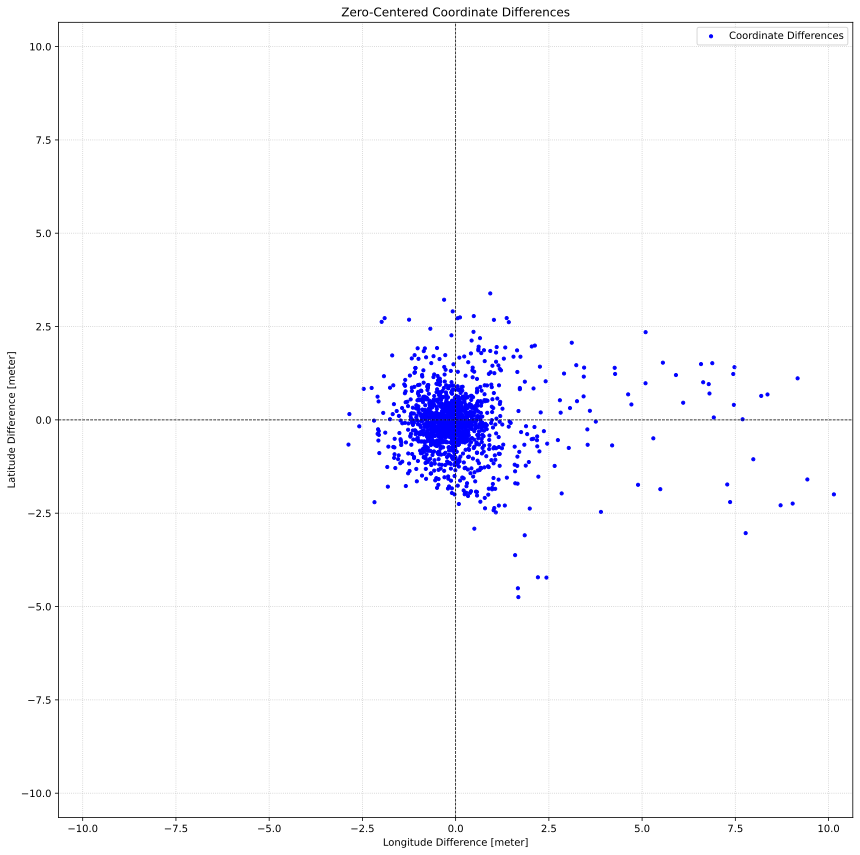

In [12]:
from geonss.plotting.distance import latlon_distance
path = latlon_distance(diff, use_arcseconds=True, filename=(get_project_output() / "latlon_sat.svg"))
display(SVG(path))

Original data points: 1440
Filtered data points: 1317
Outliers removed: 123 (8.5%)



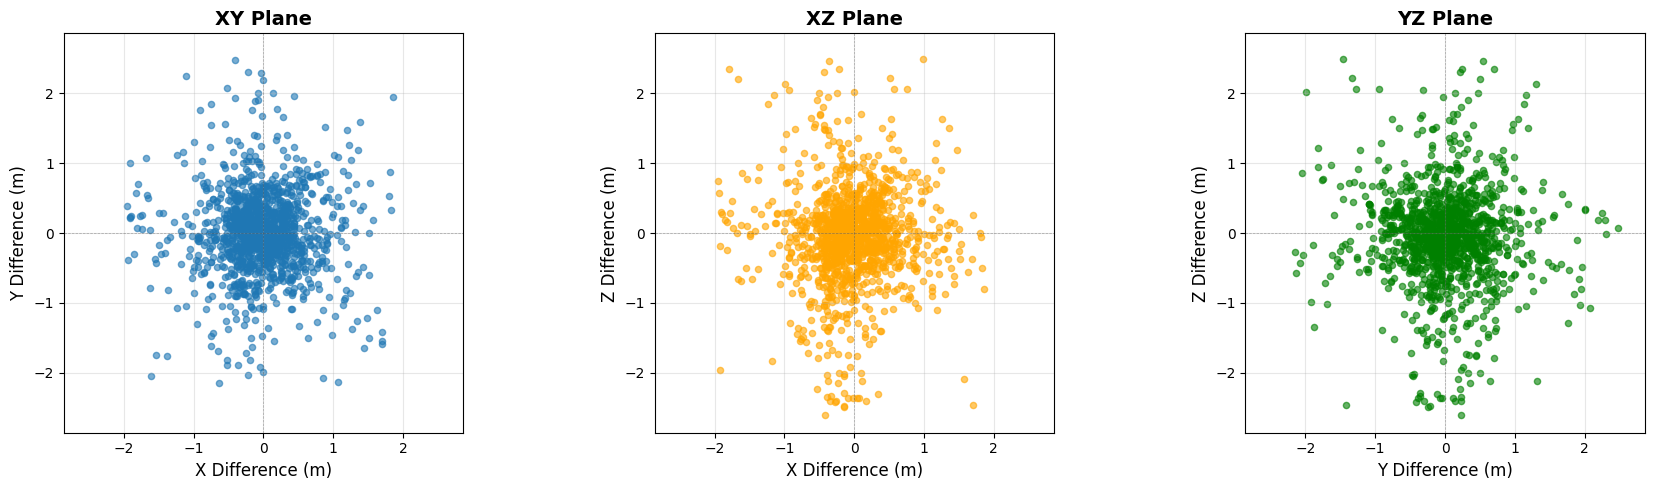

X difference: mean = -0.030 m, std = 0.551 m
Y difference: mean = 0.005 m, std = 0.603 m
Z difference: mean = -0.053 m, std = 0.690 m
Axis limit used: ±2.861 m


In [13]:
import matplotlib.pyplot as plt

# Convert diff back to ECEF for 3D plane visualization
diff_ecef = sat_pos_calc.position - sat_pos_true.position  # Shape: (time, ECEF)

# Extract X, Y, Z components
x_diff = diff_ecef.sel(ECEF='x').values
y_diff = diff_ecef.sel(ECEF='y').values
z_diff = diff_ecef.sel(ECEF='z').values

# Filter out outliers (values beyond 2 standard deviations)
x_mean, x_std = np.mean(x_diff), np.std(x_diff)
y_mean, y_std = np.mean(y_diff), np.std(y_diff)
z_mean, z_std = np.mean(z_diff), np.std(z_diff)

# Create mask for points within 2 standard deviations
mask = (np.abs(x_diff - x_mean) <= 2 * x_std) & \
       (np.abs(y_diff - y_mean) <= 2 * y_std) & \
       (np.abs(z_diff - z_mean) <= 2 * z_std)

# Apply filter
x_diff_filtered = x_diff[mask]
y_diff_filtered = y_diff[mask]
z_diff_filtered = z_diff[mask]

print(f"Original data points: {len(x_diff)}")
print(f"Filtered data points: {len(x_diff_filtered)}")
print(f"Outliers removed: {len(x_diff) - len(x_diff_filtered)} ({100*(len(x_diff) - len(x_diff_filtered))/len(x_diff):.1f}%)\n")

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Determine global axis limits for consistent scaling (using filtered data)
max_range = max(np.abs(x_diff_filtered).max(), np.abs(y_diff_filtered).max(), np.abs(z_diff_filtered).max())
axis_limit = max_range * 1.1  # Add 10% margin

# Plot XY plane
axes[0].scatter(x_diff_filtered, y_diff_filtered, alpha=0.6, s=20)
axes[0].axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
axes[0].axvline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
axes[0].set_xlabel('X Difference (m)', fontsize=12)
axes[0].set_ylabel('Y Difference (m)', fontsize=12)
axes[0].set_title('XY Plane', fontsize=14, fontweight='bold')
axes[0].set_xlim(-axis_limit, axis_limit)
axes[0].set_ylim(-axis_limit, axis_limit)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, alpha=0.3)

# Plot XZ plane
axes[1].scatter(x_diff_filtered, z_diff_filtered, alpha=0.6, s=20, color='orange')
axes[1].axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
axes[1].axvline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
axes[1].set_xlabel('X Difference (m)', fontsize=12)
axes[1].set_ylabel('Z Difference (m)', fontsize=12)
axes[1].set_title('XZ Plane', fontsize=14, fontweight='bold')
axes[1].set_xlim(-axis_limit, axis_limit)
axes[1].set_ylim(-axis_limit, axis_limit)
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, alpha=0.3)

# Plot YZ plane
axes[2].scatter(y_diff_filtered, z_diff_filtered, alpha=0.6, s=20, color='green')
axes[2].axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
axes[2].axvline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.3)
axes[2].set_xlabel('Y Difference (m)', fontsize=12)
axes[2].set_ylabel('Z Difference (m)', fontsize=12)
axes[2].set_title('YZ Plane', fontsize=14, fontweight='bold')
axes[2].set_xlim(-axis_limit, axis_limit)
axes[2].set_ylim(-axis_limit, axis_limit)
axes[2].set_aspect('equal', adjustable='box')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics (using filtered data)
print(f"X difference: mean = {np.mean(x_diff_filtered):.3f} m, std = {np.std(x_diff_filtered):.3f} m")
print(f"Y difference: mean = {np.mean(y_diff_filtered):.3f} m, std = {np.std(y_diff_filtered):.3f} m")
print(f"Z difference: mean = {np.mean(z_diff_filtered):.3f} m, std = {np.std(z_diff_filtered):.3f} m")
print(f"Axis limit used: ±{axis_limit:.3f} m")